In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,GeluSigmoidMLPfeaturized)

import torchode

seed = 1234
set_global_seed(seed)

random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(Xs.reshape(-1,1).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [7]:
mag = scaler.data_max_ - scaler.data_min_

In [8]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1,20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None
)


g = GeluSigmoidMLPfeaturized(
    dims=[6, 20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1.5,
    feat_upper_bound=1.5,
    init_type=None
)

model = FTNODE(f, g).to(device)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

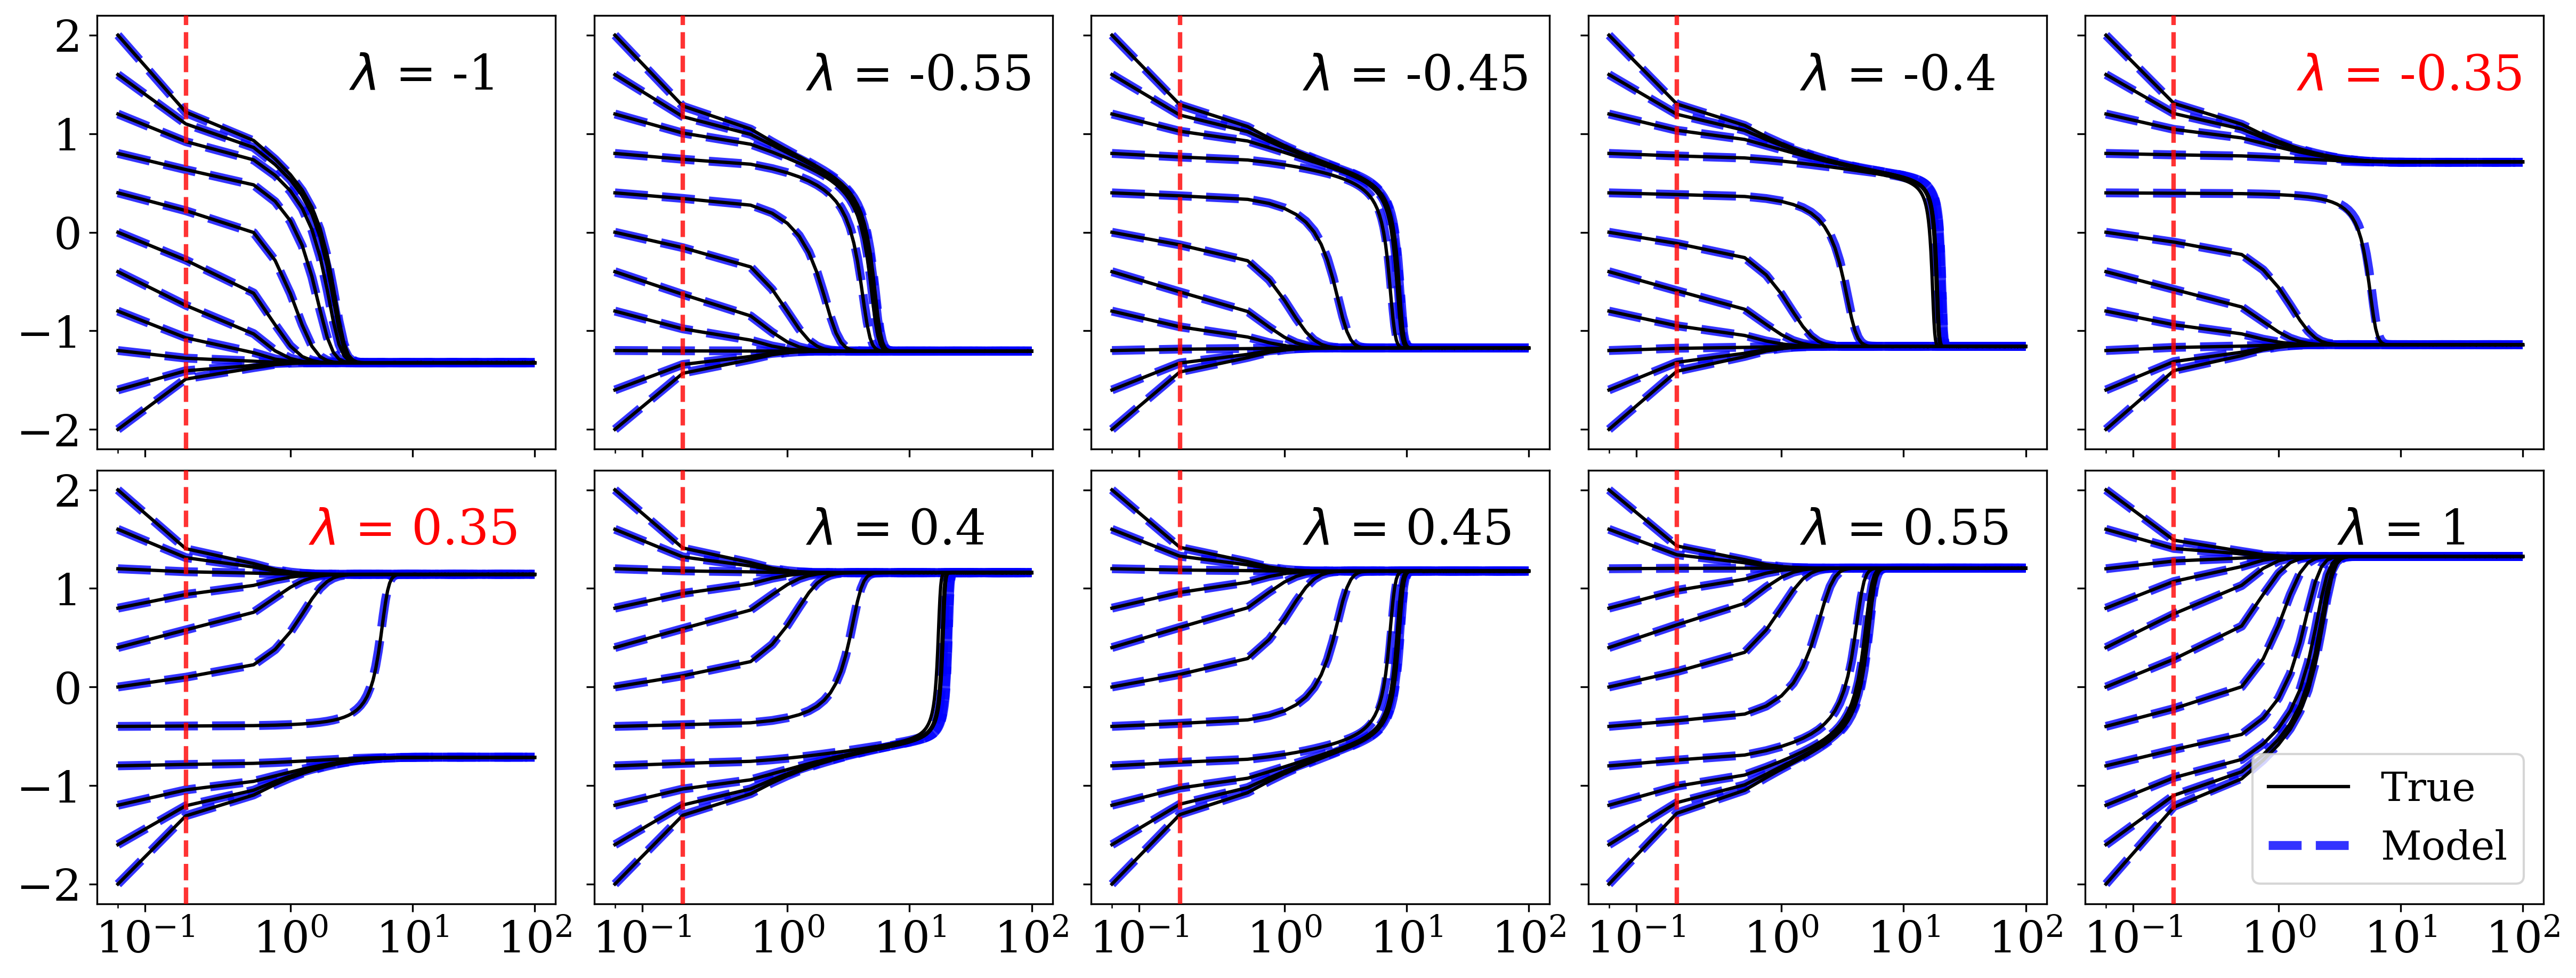

In [ ]:
lams = [-1,-0.55, -0.45, -0.4, -0.35,
        0.35,0.4,0.45,0.55,1]
n_x0 = 11
xs = np.linspace(-2,2,n_x0)
xs_scaled_tensor = torch.tensor(scaler.transform(xs.reshape(-1,1)),dtype=torch.float32)
n_colloc = 401
t_max_val = 100
ti = torch.tensor(np.linspace(0,t_max_val,n_colloc),dtype=torch.float32)

fig, axs = plt.subplots(2,5,figsize=(16,6),sharey=True, sharex=True,dpi=300,constrained_layout=True)

axs = axs.flatten()
for idx, ax in enumerate(axs):
    ax.axvline(0.25,c='red',zorder=5,lw=2,alpha=0.8, linestyle='--')
    lami = lams[idx]
    lami_tensor = torch.tensor(lami).reshape(-1,1).expand(xs_scaled_tensor.shape)
    control = lambda t: lami_tensor
    func = lambda t,x: model(t,x,control)
    with torch.no_grad():
        sol_model = torchode.solve_ivp(
            f = func,
            y0=xs_scaled_tensor,
            t_eval=ti,
            method='tsit5'
        )

    sol = sp_solve_ivp(
        hysteresis_ode,
        t_span = [0,ti[-1].item()],
        y0 = xs,
        t_eval = np.linspace(0,ti[-1].item(),n_colloc),
        args = (lami,)
    )

    y_true = sol.y.T

    y_pred = scaler.inverse_transform(sol_model.ys.reshape(-1,1)).reshape(n_x0,n_colloc).T



    for inner_idx in range(len(y_pred.T)):
        if idx == len(lams)-1 and inner_idx == 0:
            ax.plot(ti,y_true[:,inner_idx],c='black',zorder=2,lw=1.5,label="True")
            ax.plot(ti,y_pred[:,inner_idx],c='blue',linestyle='--',lw=4,alpha=0.8,zorder=1,label=r"Model")
            ax.legend(fontsize=18)

        else:
            ax.plot(ti,y_true[:,inner_idx],c='black',zorder=2,lw=1.5)
            ax.plot(ti,y_pred[:,inner_idx],c='blue',linestyle='--',lw=4,alpha=0.8,zorder=1)
    
    color = 'black'
    if lami > -np.sqrt(4/27) and lami < np.sqrt(4/27):
        color = 'red'

    if idx ==0 or idx==len(axs)-1:
        ax.text(3,1.45,rf"$\lambda$ = {lami}",fontsize=22,c=color)
    else:
        ax.text(1.4,1.45,rf"$\lambda$ = {lami}",fontsize=22,c=color)
    

    ax.set_xscale('symlog', linthresh=0.5)
    ax.set_xticks([0.1, 1,10, 100])
    ax.set_yticks([-2,-1,0,1,2])


for ax in axs:
    ax.tick_params(axis='both', which='major',labelsize=20)

plt.savefig("hysteresis_traj.png",bbox_inches='tight')
plt.show()

# All Trajectories nRMSE error

In [11]:
n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)
# mag = 4 # 2 - (-2)
xs_scaled_tensor = torch.tensor(scaler.transform(xs.reshape(-1,1)),dtype=torch.float32)

n_colloc = 401
t_max_val = 100
ti = torch.tensor(np.linspace(0,t_max_val,n_colloc),dtype=torch.float32)

nRMSE = []

for lami in tqdm(lams):
    lami_tensor = torch.tensor(lami,dtype=torch.float32).reshape(-1,1).expand(xs_scaled_tensor.shape)
    control = lambda t: lami_tensor
    func = lambda t,x: model(t,x,control)
    with torch.no_grad():
        sol_model = torchode.solve_ivp(
            f = func,
            y0=xs_scaled_tensor,
            t_eval=ti,
            method='tsit5'
        )

    sol = sp_solve_ivp(
        hysteresis_ode,
        t_span = [0,ti[-1].item()],
        y0 = xs,
        t_eval = np.linspace(0,ti[-1].item(),n_colloc),
        args = (lami,)
    )


    y_true = sol.y.T

    y_pred = scaler.inverse_transform(sol_model.ys.reshape(-1,1)).reshape(n_traj,n_colloc).T

    nRMSE.append(np.linalg.norm(y_true-y_pred, axis=0) / (np.sqrt(n_colloc)*mag))

nRMSE = np.array(nRMSE)

  0%|          | 0/51 [00:00<?, ?it/s]

In [13]:
nRMSE.mean(),nRMSE.std()

(0.0012102817306787904, 0.011323609947416524)